In [1]:
# 神经网络
# 如何构建神经网络
# 神经网络的结构：
# 输入层：输入层是神经网络的第一层，它负责接收外部输入数据。每个输入特征对应一个输入节点。
# 隐藏层：隐藏层是神经网络的中间层，它负责对输入数据进行特征提取和转换。每个隐藏层节点都与前一层的所有节点相连，并且每个连接都有一个权重。
# 输出层：输出层是神经网络的最后一层，它负责输出最终的预测结果。每个输出节点对应一个预测类别或连续值。
# 激活函数：在隐藏层和输出层之间，每个节点都有一个激活函数。激活函数的作用是将节点的输入映射到一个非线性的输出空间，以便模型可以学习复杂的模式。
# 损失函数：损失函数用于衡量模型预测结果与真实标签之间的差异。常用的损失函数包括均方误差（MSE）、交叉熵损失（Cross-Entropy Loss）等。
# 优化算法：优化算法用于更新神经网络的权重，以最小化损失函数。常用的优化算法包括梯度下降（Gradient Descent）、随机梯度下降（Stochastic Gradient Descent）、Adam等。

# 神经网络的训练
# 前向传播：从输入层开始，依次计算每个隐藏层节点的输出，直到输出层。这个过程称为前向传播。
# 损失计算：将输出层的预测结果与真实标签进行比较，计算损失值。
# 反向传播：从输出层开始，根据损失值计算每个连接的梯度，然后反向传播到隐藏层。这个过程称为反向传播。
# 权重更新：根据反向传播计算得到的梯度，使用优化算法更新神经网络的权重。
# 迭代训练：重复执行前向传播、损失计算、反向传播和权重更新步骤，直到模型收敛或满足停止条件。

#相邻层之间的连接
#每个隐藏层节点都与前一层的所有节点相连，并且每个连接都有一个权重。
#每个输出节点都与隐藏层的所有节点相连，并且每个连接都有一个权重。
#同层神经元一般不连接，不同层神经元之间的连接称为全连接层。

#每个神经元的功能
#每个神经元都负责对输入数据进行特征提取和转换。
#每个神经元的输出是前一层所有节点的加权和加上偏置项，然后通过激活函数进行映射。


#导包
import torch
import torch.nn as nn
from torchsummary import summary
import numpy as np


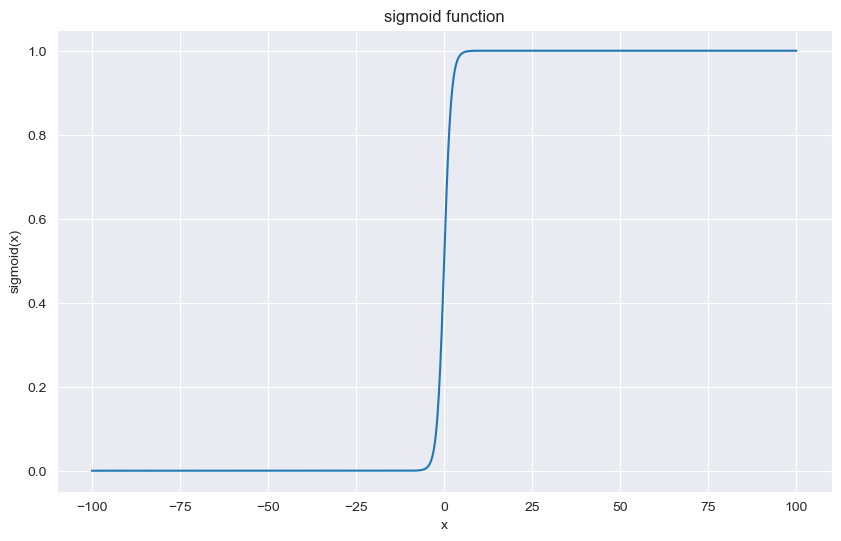

In [2]:
#激活函数的介绍
#激活函数的作用是将神经网络的输出映射到一个特定的范围内，例如[0,1]或[-1,1]。
#常用的激活函数有Sigmoid函数、Tanh函数、ReLU函数等。

#sigmoid函数
#sigmoid函数的公式为：
#sigmoid(x)=1/(1+e^(-x))
#sigmoid函数的输出范围为[0,1]，它是一个平滑的S型曲线。
#sigmoid函数的导数为sigmoid(x)*(1-sigmoid(x))
#sigmoid函数在神经网络中常用于二分类问题。常用在输出层，将输出映射到[0,1]之间，代表样本属于正类的概率。

#优缺点
#sigmoid函数的优点是输出范围在[0,1]之间，这使得它在处理概率问题时非常方便。
#sigmoid函数的缺点是当输入值非常大或非常小时，sigmoid函数的导数接近于0，这会导致梯度消失问题。
#为了解决梯度消失问题，引入了Tanh函数。

#图像绘制
import matplotlib.pyplot as plt
import seaborn as sns
import torch
x=torch.linspace(-100,100,1000)
y=torch.sigmoid(x)
plt.figure(figsize=(10,6),dpi=100)
sns.lineplot(x=x,y=y)
plt.title('sigmoid function')
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.show()

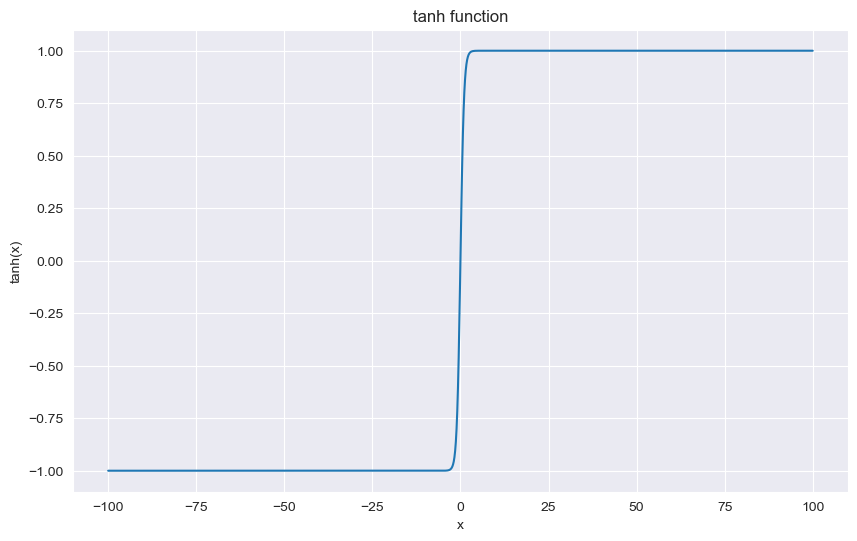

In [3]:

#tanh函数
#tanh函数的公式为：
#tanh(x)=(e^x-e^(-x))/(e^x+e^(-x))
#tanh函数的输出范围为[-1,1]，它是一个平滑的双曲正切曲线。
#tanh函数的导数为1-tanh(x)^2
#tanh函数在神经网络中常用于隐藏层，将输出映射到[-1,1]之间。

#优缺点
#tanh函数的优点是输出范围在[-1,1]之间，这使得它在处理数据时比sigmoid函数更方便。
#tanh函数的缺点是当输入值非常大或非常小时，tanh函数的导数接近于0，这也会导致梯度消失问题。
#为了解决梯度消失问题，引入了ReLU函数。

#图像绘制
plt.figure(figsize=(10,6),dpi=100)
x=torch.linspace(-100,100,1000)
y=torch.tanh(x)
sns.lineplot(x=x,y=y)
plt.title('tanh function')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.show()

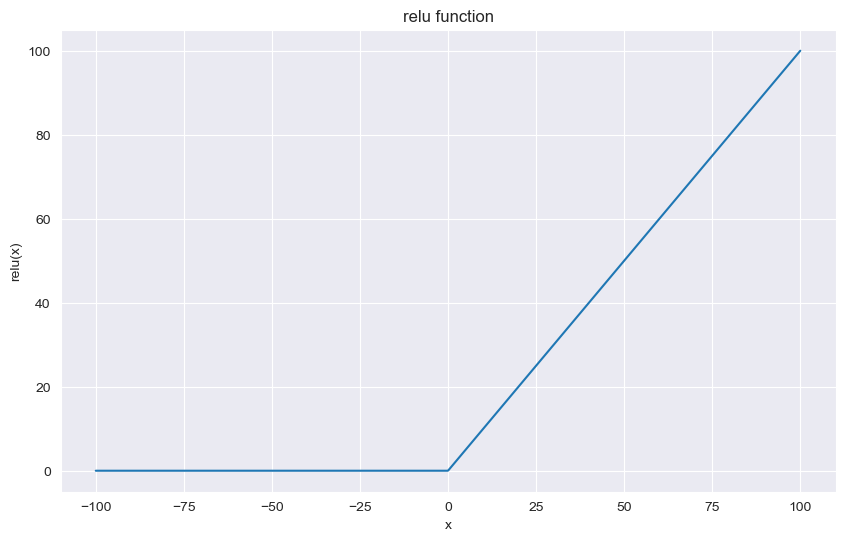

In [4]:

#ReLU函数
#ReLU函数的公式为：
#ReLU(x)=max(0,x)
#ReLU函数的输出范围为[0,∞)，它是一个非饱和函数，当输入值大于0时，输出值等于输入值；当输入值小于等于0时，输出值为0。
#ReLU函数的导数为1，当输入值大于0时，导数为1；当输入值小于等于0时，导数为0。
#ReLU函数在神经网络中常用于隐藏层，将输出映射到[0,∞)之间。与sigmoid函数不同，ReLU函数在输入值小于等于0时，输出值为0，而不是0.5。这使得ReLU函数在训练神经网络时收敛更快。

#优缺点
#优点：
#1. ReLU函数简单快速，计算量小。
#2. ReLU函数在输入值大于0时，导数为1，这使得在反向传播时梯度不会消失。
#3. ReLU函数在训练神经网络时收敛更快，因为它避免了sigmoid函数在输入值较大时的梯度饱和问题。
#4.ReLU函数在输入值小于等于0时，输出值为0，这使得在反向传播时梯度为0，从而避免了梯度消失问题。会导致神经元的死亡（即输出为0），从而影响模型的训练。

#图像绘制
plt.figure(figsize=(10,6),dpi=100)
x=torch.linspace(-100,100,1000)
y=torch.relu(x)
sns.lineplot(x=x,y=y)
plt.title('relu function')
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.show()


In [5]:
#softmax激活函数
#softmax函数将一个向量映射到一个概率分布，每个元素的取值范围在[0,1]之间，且所有元素的和为1。
#softmax函数通常用于多分类问题的输出层，将模型的输出转换为概率分布，方便进行分类预测。
#softmax函数的公式为：
#softmax(x_i) = exp(x_i) / sum(exp(x_j))
#其中，x_i表示第i个元素，exp(x_i)表示e的x_i次方，sum(exp(x_j))表示所有元素的指数和。

#优缺点
#优点：
#1. softmax函数简单快速，计算量小。
#2. softmax函数在多分类问题中，将模型的输出转换为概率分布，方便进行分类预测。
#3. softmax函数在反向传播时，梯度计算简单，易于实现。

#缺点：
#1. softmax函数在输入值较大时，会导致梯度饱和问题，从而影响模型的训练。
#2. softmax函数在输入值较小时，会导致概率分布的差异较小，从而影响模型的分类效果。

In [6]:
#参数初始化
#在神经网络中，参数初始化是一个重要的问题。如果参数初始化不当，会导致模型训练过程中的梯度消失或爆炸问题，从而影响模型的收敛速度和性能。
#常用的参数初始化方法包括随机初始化、Xavier初始化、He初始化等。
#参数初始化的作用是为了确保模型在训练过程中能够正常收敛。


#随机初始化
#随机初始化是指将参数随机赋值为一个小的随机数，例如从均匀分布或正态分布中采样。
#随机初始化的优点是简单快速，不需要考虑其他因素。
#随机初始化的缺点是可能导致模型训练过程中的梯度消失或爆炸问题，从而影响模型的收敛速度和性能。 
# 适用于：
# 1. 简单的神经网络模型
# 2. 输入特征维度较低的情况
# 3. 模型结构比较简单的情况


# #为什么会出现梯度消失或爆炸问题？
#梯度消失或爆炸问题是指在神经网络训练过程中，梯度值变得非常小或非常大，从而导致模型参数更新缓慢或根本无法更新。
#这通常是由于模型结构复杂或参数初始化不当导致的。
#例如，在深度神经网络中，使用随机初始化可能会导致梯度消失问题，因为在反向传播过程中，梯度值会被多次乘以权重矩阵，导致梯度值变得非常小。
#而在使用He初始化时，参数初始化的范围是根据层数和输入维度来确定的，从而避免了梯度消失问题。

#随机初始化的方法
#随机初始化的方法有很多种，例如从均匀分布或正态分布中采样。
#在PyTorch中，随机初始化可以通过nn.init.uniform_(),nn.init.normal_()函数来实现。
#例如，nn.init.uniform_()函数的取值区间是[-0.01,0.01)，也可以通过参数a和b来指定其他取值区间。
#而nn.init.normal_()函数的取值区间是服从标准正态分布的随机数。

#全0初始化：nn.init.zeros_()
#全0初始化是指将参数全部赋值为0。
#全0初始化的优点是简单快速，不需要考虑其他因素。
#全0初始化的缺点是可能导致模型训练过程中的梯度消失问题，从而影响模型的收敛速度和性能。
#因此，全0初始化通常只用于调试或特殊情况，而在实际应用中，一般不推荐使用。

#全1初始化：nn.init.ones_()
#全1初始化是指将参数全部赋值为1。
#全1初始化的优点是简单快速，不需要考虑其他因素。
#全1初始化的缺点是可能导致模型训练过程中的梯度爆炸问题，从而影响模型的收敛速度和性能。
#因此，全1初始化通常只用于调试或特殊情况，而在实际应用中，一般不推荐使用。

#固定值初始化：nn.init.constant_()
#固定值初始化是指将参数全部赋值为一个固定的数值，例如0.1、0.01等。
#固定值初始化的优点是简单快速，不需要考虑其他因素。
#固定值初始化的缺点是可能导致模型训练过程中的梯度消失或爆炸问题，从而影响模型的收敛速度和性能。
#因此，固定值初始化通常只用于调试或特殊情况，而在实际应用中，一般不推荐使用。


In [7]:
#kaiming初始化：nn.init.kaiming_uniform_()和nn.init.kaiming_normal_()
#kaiming初始化是指根据He初始化的方法，将参数初始化为服从均匀分布或正态分布的随机数。
#kaiming初始化的优点是可以有效避免梯度消失或爆炸问题，从而提高模型的收敛速度和性能。
#kaiming初始化的缺点是需要根据不同的激活函数选择不同的初始化方法，例如ReLU、LeakyReLU等。适用于ReLU和其变体激活函数。

#kaiming初始化的方法
#kaiming初始化的方法有两种，分别是均匀分布初始化和正态分布初始化。
#均匀分布初始化的方法是nn.init.kaiming_uniform_()，取值区间是[-sqrt(6/fan_in),sqrt(6/fan_in)]，其中fan_in是输入的通道数。
#正态分布初始化的方法是nn.init.kaiming_normal_()，取值区间是[0,sqrt(2/fan_in)]，其中fan_in是输入的通道数。

#xavier初始化：nn.init.xavier_uniform_()和nn.init.xavier_normal_()
#xavier初始化是指根据Glorot初始化的方法，将参数初始化为服从均匀分布或正态分布的随机数。
#xavier初始化的优点是可以有效避免梯度消失或爆炸问题，从而提高模型的收敛速度和性能。
#xavier初始化的缺点是需要根据不同的激活函数选择不同的初始化方法，例如sigmoid、tanh等。适用于sigmoid和tanh等激活函数。

#xavier初始化的方法
#xavier初始化的方法有两种，分别是均匀分布初始化和正态分布初始化。
#均匀分布初始化的方法是nn.init.xavier_uniform_()，取值区间是[-sqrt(6/(fan_in+fan_out)),sqrt(6/(fan_in+fan_out))]，其中fan_in是输入的通道数，fan_out是输出的通道数。
#正态分布初始化的方法是nn.init.xavier_normal_()，取值区间是[0,sqrt(2/(fan_in+fan_out))]，其中fan_in是输入的通道数，fan_out是输出的通道数。

In [8]:
#参数初始化示例
# 均匀分布初始化：nn.init.uniform_()
# 均匀分布初始化是指将参数从均匀分布中随机采样。
# 均匀分布初始化的优点是简单快速，不需要考虑其他因素。
# 均匀分布初始化的缺点是可能导致模型训练过程中的梯度消失或爆炸问题，从而影响模型的收敛速度和性能。
# 因此，均匀分布初始化通常只用于调试或特殊情况，而在实际应用中，一般不推荐使用。
linear=nn.Linear(5,3)
nn.init.uniform_(linear.weight)
nn.init.uniform_(linear.bias)
print(linear.weight.data)
print(linear.bias.data) #加不加data的区别：data是张量的属性，用于访问张量的实际数据，而不加data是访问张量的其他属性，例如形状、数据类型等。

#kaiming初始化：nn.init.kaiming_uniform_()
# kaiming初始化是指将参数从kaiming分布中随机采样。
# kaiming初始化的优点是可以有效避免梯度消失或爆炸问题，从而提高模型的收敛速度和性能。
# kaiming初始化的缺点是需要考虑激活函数的类型，不同的激活函数有不同的kaiming分布。
# 因此，在使用kaiming初始化时，需要根据具体的激活函数类型选择合适的初始化方法。
lineaar=nn.Linear(4,3)
nn.init.kaiming_uniform_(linear.weight)
print(linear.weight.data)

#xavier初始化：nn.init.xavier_uniform_()
# xavier初始化是指将参数从xavier分布中随机采样。
# xavier初始化的优点是可以有效避免梯度消失或爆炸问题，从而提高模型的收敛速度和性能。
# xavier初始化的缺点是需要考虑激活函数的类型，不同的激活函数有不同的xavier分布。
# 因此，在使用xavier初始化时，需要根据具体的激活函数类型选择合适的初始化方法。
lineaar=nn.Linear(4,3)
nn.init.xavier_uniform_(linear.weight)
print(linear.weight.data)


tensor([[0.5567, 0.9323, 0.2754, 0.6351, 0.9397],
        [0.0564, 0.1721, 0.6152, 0.5570, 0.1310],
        [0.0325, 0.2520, 0.3197, 0.1275, 0.6277]])
tensor([0.6805, 0.8921, 0.9825])
tensor([[-0.0351, -0.0093, -0.0998,  0.4408, -0.7302],
        [ 0.0290,  0.9726, -0.7474, -0.4191, -1.0854],
        [ 0.3691, -1.0597,  0.9845,  0.7754,  0.7525]])
tensor([[-0.4997, -0.1692, -0.7414,  0.1350, -0.3801],
        [ 0.3258,  0.4309, -0.6605,  0.6027, -0.2328],
        [ 0.4218,  0.0948,  0.1847,  0.1912, -0.7494]])


In [18]:
#神经网络搭建流程
# 1. 定义神经网络模型
# 2. 定义损失函数
# 3. 定义优化器
# 4. 训练模型
# 5. 评估模型

#
#1. 定义神经网络模型
# 神经网络模型是指由多个层（layer）组成的计算图，用于对输入数据进行处理和映射到输出结果。
# 在PyTorch中，神经网络模型可以通过继承nn.Module类来定义，
# 并在__init__方法中定义模型的层结构，
# 在forward方法中定义前向传播的计算过程。
# 以下是一个简单的神经网络模型示例：
# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()
#         self.fc1 = nn.Linear(784, 256)
#         self.fc2 = nn.Linear(256, 128)
#         self.fc3 = nn.Linear(128, 10)
#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

#演示神经网络搭建
class Net(nn.Module):
    #定义神经网络模型,完成搭建和参数初始化
    #参数初始化采用Xavier初始化和Kaiming初始化
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(3,3)
        self.fc2=nn.Linear(3,2)
        self.output=nn.Linear(2,2)

        #参数初始化
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.kaiming_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)
    #定义前向传播过程
    def forward(self,x):
        x=torch.sigmoid(self.fc1(x))
        x=torch.relu(self.fc2(x))
        x=torch.softmax(self.output(x),dim=1) #dim=1表示按行取softmax,dim=-1表示按最后一维取softmax
        return x


       








In [ ]:
# 模型训练
#示例
model1=Net()
print(model1)
#创建数据集
data=torch.randn(5,3)
print(data.shape)
print(data.requires_grad)

#调用模型进行预测
output=model1(data)  #调用模型进行前向传播
print(output)
print(output.shape)
print(output.requires_grad)

#计算模型参数
summary(model1,input_size=(3,),batch_size=5) #input_size=(3,)表示输入数据的维度为（3，）,batch_size=5表示每次输入5个样本，一个批次的样本数为5


Net(
  (fc1): Linear(in_features=3, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=2, bias=True)
)
torch.Size([5, 3])
False
tensor([[0.2591, 0.7409],
        [0.2591, 0.7409],
        [0.2120, 0.7880],
        [0.2602, 0.7398],
        [0.2444, 0.7556]], grad_fn=<SoftmaxBackward0>)
torch.Size([5, 2])
True
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [5, 1, 3]              12
            Linear-2                  [5, 1, 2]               8
            Linear-3                  [5, 1, 2]               6
Total params: 26
Trainable params: 26
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
---------------------------------------------

In [ ]:
#损失函数
#损失函数用于衡量模型预测值与真实值之间的差异。
#在神经网络中，常用的损失函数包括均方误差（MSE）、交叉熵损失（CrossEntropyLoss）等。
#以下是一个示例，演示如何使用均方误差损失函数：
# #导入均方误差损失函数
# from torch.nn import MSELoss
# #创建均方误差损失函数对象
# mse_loss=MSELoss()
# #计算模型预测值与真实值之间的均方误差
# output=model1(data)  #调用模型进行前向传播
# target=torch.randn(5,2)  #创建随机的真实值
# loss=mse_loss(output,target)  #计算均方误差损失
# print(loss)

#多分类任务损失函数
#在多分类任务中，常用的损失函数是交叉熵损失（CrossEntropyLoss）。 该损失函数用于衡量模型预测的概率分布与真实标签之间的差异，已包含了softmax函数。
#函数的原理
#交叉熵损失函数的原理是基于信息论中的熵概念。 熵表示随机变量的不确定性，而交叉熵则衡量两个概率分布之间的差异。
#在多分类任务中，模型的输出是一个概率分布，每个类别的概率表示模型对该样本属于该类别的置信度。 真实标签是一个one-hot编码的向量，其中只有一个元素为1，其他元素为0。
#交叉熵损失函数的计算如下：
#loss=−∑i=1n(yi⋅log(yi^))
#其中，n是类别数量，yi是真实标签的第i个元素，yi^是模型预测的第i个类别的概率。
#以下是一个示例，演示如何使用交叉熵损失函数：
#导入交叉熵损失函数
from torch.nn import CrossEntropyLoss
#创建交叉熵损失函数对象
ce_loss=CrossEntropyLoss()
#计算模型预测值与真实值之间的交叉熵损失
y_true=torch.tensor([[0,0,1],[0,1,0]],dtype=torch.float32) #真实标签,one-hot编码,每个样本只有一个类别为1,注意要转换为float32类型
y_pred=torch.tensor([[0.2,0.2,0.7],[0.3,0.6,0.2]]) #模型预测值
loss=ce_loss(y_pred,y_true)
print(loss)



tensor(0.8372)


ValueError: Using a target size (torch.Size([2, 1])) that is different to the input size (torch.Size([2, 2])) is deprecated. Please ensure they have the same size.

In [ ]:

#二分类任务损失函数
#在二分类任务中，常用的损失函数是二分类交叉熵损失（BinaryCrossEntropyLoss）。 该损失函数用于衡量模型预测的二分类概率与真实标签之间的差异。
#函数的原理
#二分类交叉熵损失函数的原理与多分类交叉熵损失函数类似，只是在计算时只考虑了两个类别（0和1）。需要使用sigmoid函数将模型输出转换为二分类概率。
#二分类交叉熵损失函数的计算如下：
#loss=−(y⋅log(yi^)+(1−y)⋅log(1−yi^))
#其中，y是真实标签（0或1），yi^是模型预测的二分类概率。
#以下是一个示例，演示如何使用二分类交叉熵损失函数：
#导入二分类交叉熵损失函数
from torch.nn import BCELoss
#创建二分类交叉熵损失函数对象
bce_loss=BCELoss()
#计算模型预测值与真实值之间的二分类交叉熵损失
y_true=torch.tensor([[1,0],[1,0]],dtype=torch.float32) #真实标签,注意要转换为float32类型
y_pred=torch.tensor([[0.2,0.8],[0.7,0.3]]) #模型预测值
loss=bce_loss(y_pred,y_true)
print(loss)




tensor(0.9831)


In [ ]:
#MAE
#平均绝对误差（Mean Absolute Error，MAE）是一种常用的回归损失函数，用于衡量预测值与真实值之间的平均绝对差异。
#MAE的计算如下：
#loss=1n∑i=1n|yi^−yi|
#MAE的计算过程如下：
#1. 对每个样本，计算预测值与真实值之间的绝对差异。
#2. 对所有样本的绝对差异取平均值，得到MAE损失值。
#MAE的优点是对异常值不敏感，因为它只考虑了绝对差异。然而，它对预测值与真实值的差异没有考虑方向，因此在某些情况下可能不是最优的损失函数。
#是L1损失函数的一种特殊情况，因为它只考虑了绝对差异，而不考虑差异的方向。

#优缺点
#MAE的优点是对异常值不敏感，因为它只考虑了绝对差异。然而，它对预测值与真实值的差异没有考虑方向，因此在某些情况下可能不是最优的损失函数。
#MAE的缺点是对异常值不敏感，因为它只考虑了绝对差异。这可能会导致模型对异常值过拟合，从而影响模型的泛化能力。

y_pred=torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)
y_true=torch.tensor([[1,1,1],[0,0,0]],dtype=torch.float32)
mae_loss=torch.nn.L1Loss()
loss=mae_loss(y_pred,y_true)
print(loss)


tensor(3.)


In [ ]:
#MSE
#均方误差（Mean Squared Error，MSE）是一种常用的回归损失函数，用于衡量预测值与真实值之间的平均平方差异。
#MSE的计算如下：
#loss=1n∑i=1n(yi^−yi)2
#MSE的计算过程如下：
#1. 对每个样本，计算预测值与真实值之间的平方差异。
#2. 对所有样本的平方差异取平均值，得到MSE损失值。
#MSE的优点是对异常值敏感，因为它考虑了差异的方向。然而，它对预测值与真实值的差异没有考虑方向，因此在某些情况下可能不是最优的损失函数。
#是L2损失函数的一种特殊情况，因为它只考虑了差异的平方，而不考虑差异的方向。

#优缺点
#MSE的优点是对异常值敏感，因为它考虑了差异的方向。然而，它对预测值与真实值的差异没有考虑方向，因此在某些情况下可能不是最优的损失函数。
#MSE的缺点是对异常值敏感，因为它对异常值的平方差异有较大的贡献。这可能会导致模型对异常值过拟合，从而影响模型的泛化能力。
#为了解决MSE对异常值敏感的问题，引入了均方绝对误差（Mean Absolute Error，MAE）损失函数。

y_pred=torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)
y_true=torch.tensor([[1,1,1],[0,0,0]],dtype=torch.float32)
mse_loss=torch.nn.MSELoss()
loss=mse_loss(y_pred,y_true)
print(loss)


tensor(13.6667)


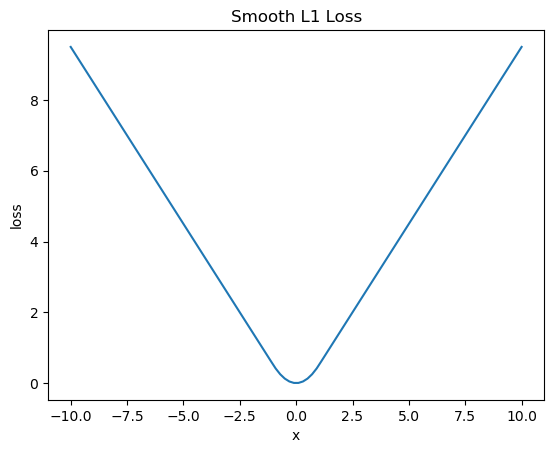

tensor(2.5833)


In [ ]:
#Smooth L1 Loss
#Smooth L1损失函数是一种常用的回归损失函数，用于衡量预测值与真实值之间的差异。
#它结合了L1损失函数和L2损失函数的优点，对异常值不敏感，同时对预测值与真实值的差异有考虑方向。
#Smooth L1损失函数的计算如下：
#loss=1n∑i=1n{0.5(yi^−yi)2if|yi^−yi|≤11|yi^−yi|−0.5if|yi^−yi|>1
#Smooth L1损失函数的计算过程如下：
#1. 对每个样本，计算预测值与真实值之间的差异。
#2. 如果差异的绝对值小于等于1，将差异的平方除以2，得到L2损失。
#3. 如果差异的绝对值大于1，将差异的绝对值减去0.5，得到L1损失。
#4. 对所有样本的损失取平均值，得到Smooth L1损失值。

#Smooth L1损失函数的图像如下：
import matplotlib.pyplot as plt
import numpy as np
x=np.linspace(-10,10,100)
y=np.where(np.abs(x)<=1,0.5*x**2,np.abs(x)-0.5) #np.where(条件,满足条件时的值,不满足条件时的值)
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('loss')
plt.title('Smooth L1 Loss')
plt.show()


#示例
#假设我们有一个简单的线性回归模型，预测值为y_pred，真实值为y_true。
#我们可以使用Smooth L1损失函数来计算模型的损失值。
y_pred=torch.tensor([[1,2,3],[4,5,6]],dtype=torch.float32)
y_true=torch.tensor([[1,1,1],[0,0,0]],dtype=torch.float32)
smooth_l1_loss=torch.nn.SmoothL1Loss()
loss=smooth_l1_loss(y_pred,y_true)
print(loss)